# Assignment 13: LGBM & XGBM – Diabetes Classification

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.impute import SimpleImputer

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

ModuleNotFoundError: No module named 'lightgbm'

## 1. Load the Dataset

In [5]:
file_path = r"C:\Users\Admin\OneDrive\Desktop\Data Science ExcelR\Assignments\Assignment 13\diabetes.csv"

import os

if os.path.exists(file_path):
    data = pd.read_csv(file_path)
else:
    # Uploaded file location in this environment
    data = pd.read_csv("/mnt/data/diabetes(2).csv")

print("Dataset loaded successfully.")
print("Shape:", data.shape)
display(data.head())

Dataset loaded successfully.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
#information about the dataset
print("Dataset Information:")
print("-" * 60)
data.info()

print("\nSummary Statistics:")
display(data.describe().T)

Dataset Information:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Exploratory Data Analysis (EDA)

In [7]:
# Check missing values
missing_summary = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing Percentage": (data.isnull().sum() / len(data) * 100).round(2)
})

display(missing_summary)

print("Duplicate rows:", data.duplicated().sum())

,Missing Count,Missing Percentage
Pregnancies,0,0.0
Glucose,0,0.0
BloodPressure,0,0.0
SkinThickness,0,0.0
Insulin,0,0.0
BMI,0,0.0
DiabetesPedigreeFunction,0,0.0
Age,0,0.0
Outcome,0,0.0


Duplicate rows: 0


Outcome distribution:


,Count
Outcome,
0,500
1,268


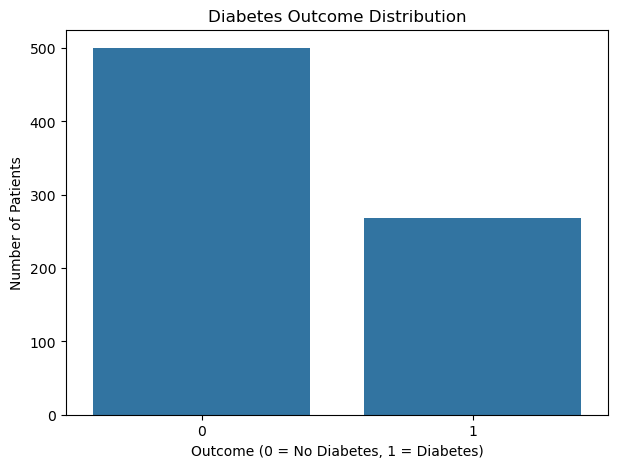

In [8]:
# Check target class distribution
print("Outcome distribution:")
display(data["Outcome"].value_counts().rename_axis("Outcome").to_frame("Count"))

plt.figure(figsize=(7, 5))
sns.countplot(data=data, x="Outcome")
plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")
plt.show()

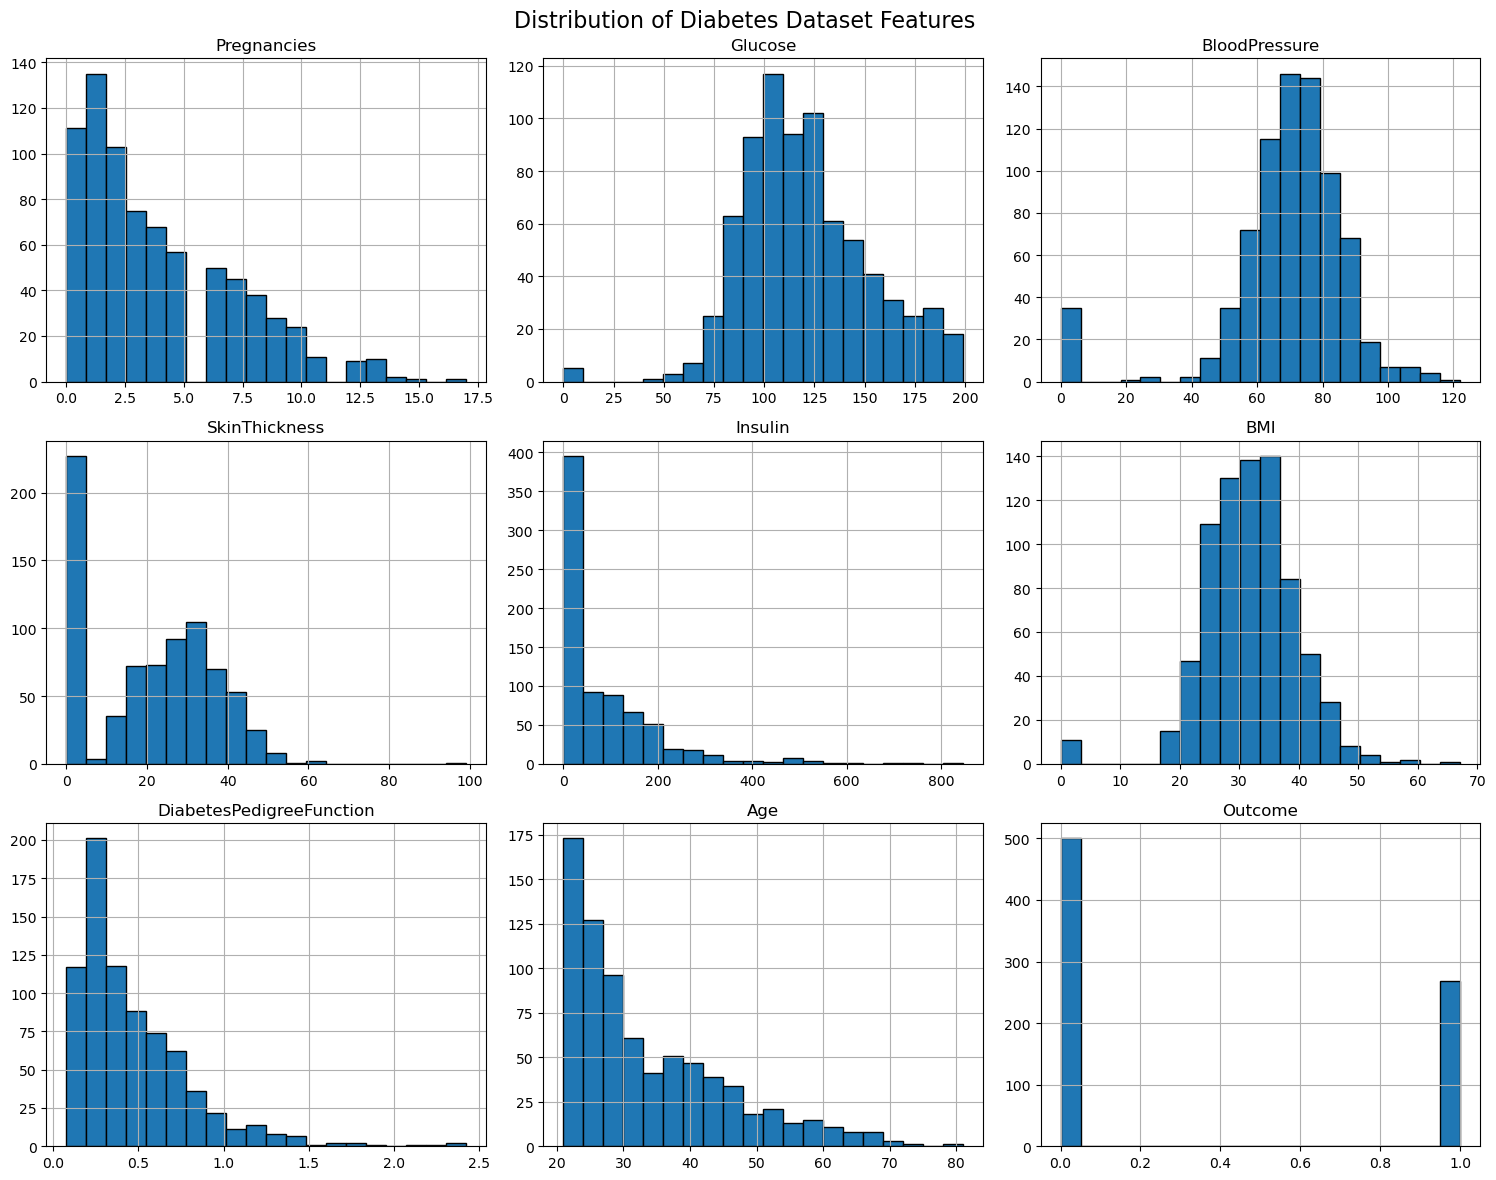

In [10]:
# Histograms for numerical variables
data.hist(figsize=(15, 12), bins=20, edgecolor="black")
plt.suptitle("Distribution of Diabetes Dataset Features", fontsize=16)
plt.tight_layout()
plt.show()

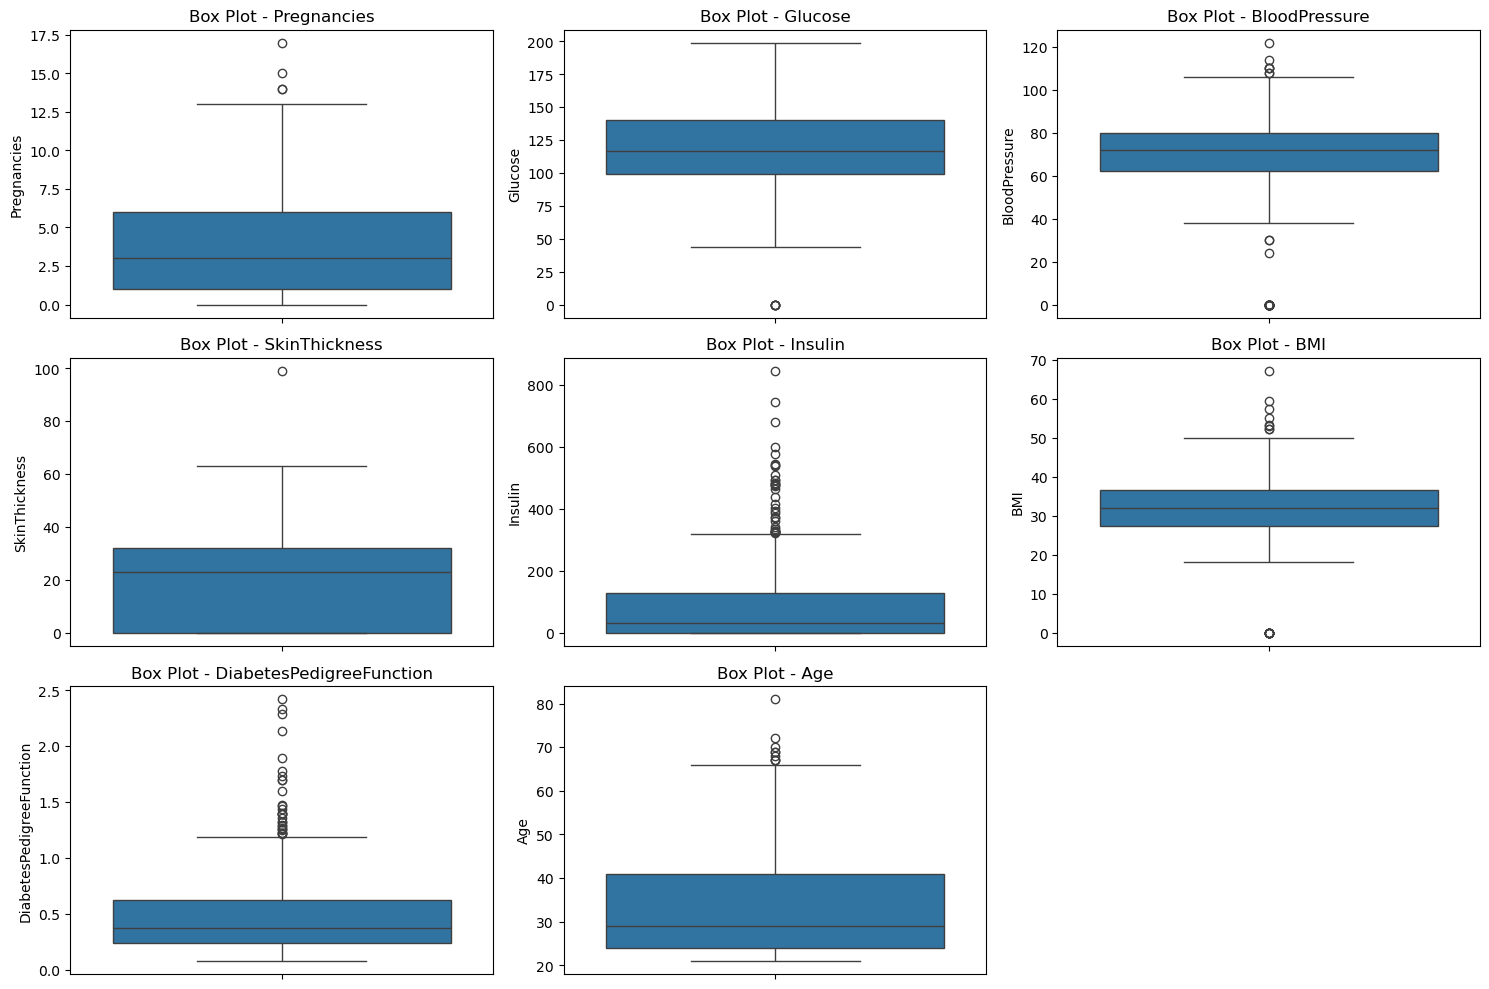

In [11]:
# Box plots to identify outliers
numeric_features = data.columns.drop("Outcome")

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=data[col])
    plt.title(f"Box Plot - {col}")
plt.tight_layout()
plt.show()

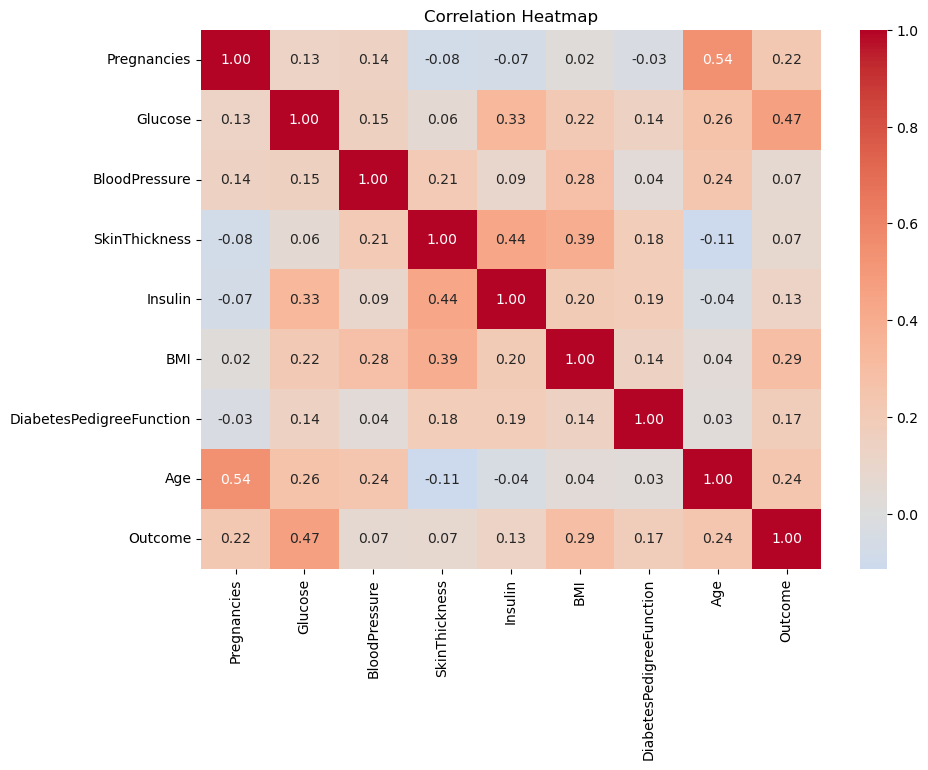

In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

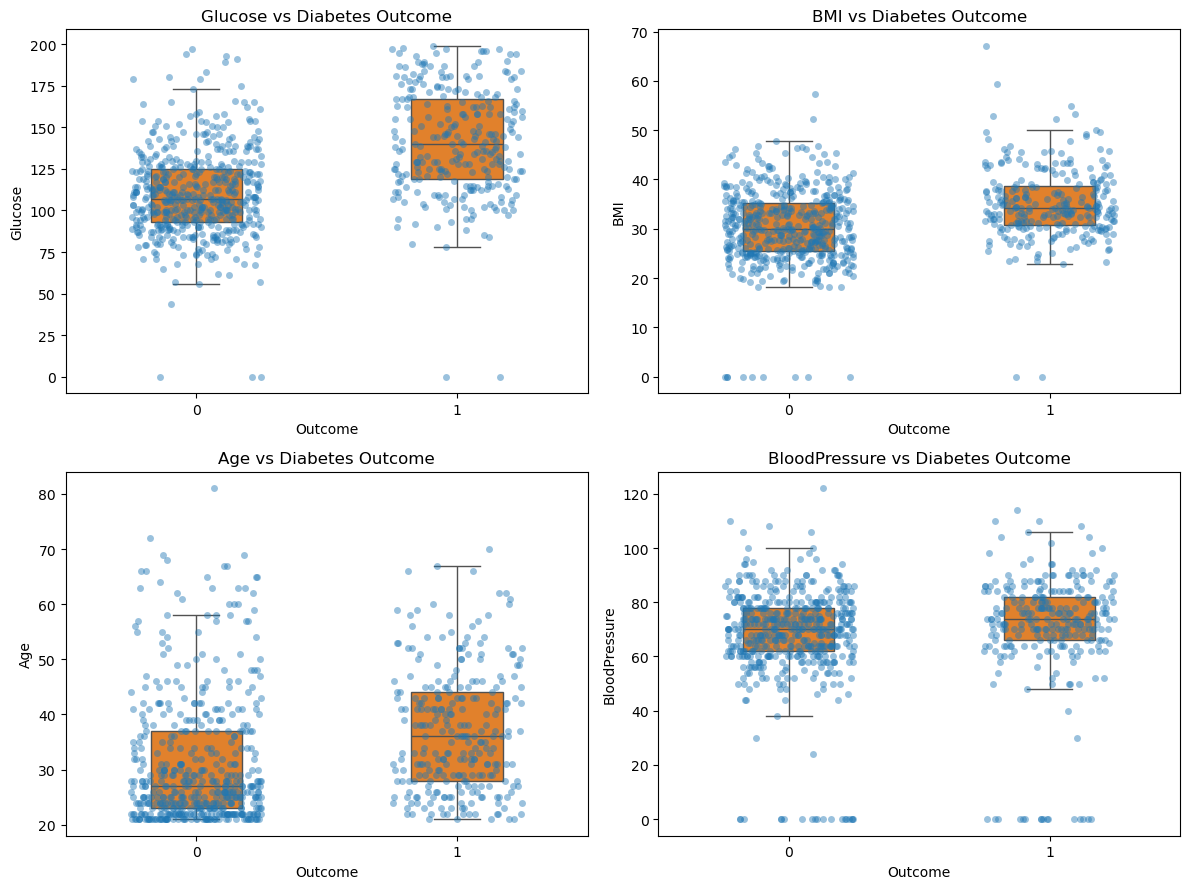

In [13]:
# Scatter plots: selected features versus Outcome
selected_features = ["Glucose", "BMI", "Age", "BloodPressure"]

plt.figure(figsize=(12, 9))
for i, col in enumerate(selected_features, 1):
    plt.subplot(2, 2, i)
    sns.stripplot(data=data, x="Outcome", y=col, jitter=0.25, alpha=0.45)
    sns.boxplot(data=data, x="Outcome", y=col, width=0.35, showfliers=False)
    plt.title(f"{col} vs Diabetes Outcome")
    plt.xlabel("Outcome")
plt.tight_layout()
plt.show()

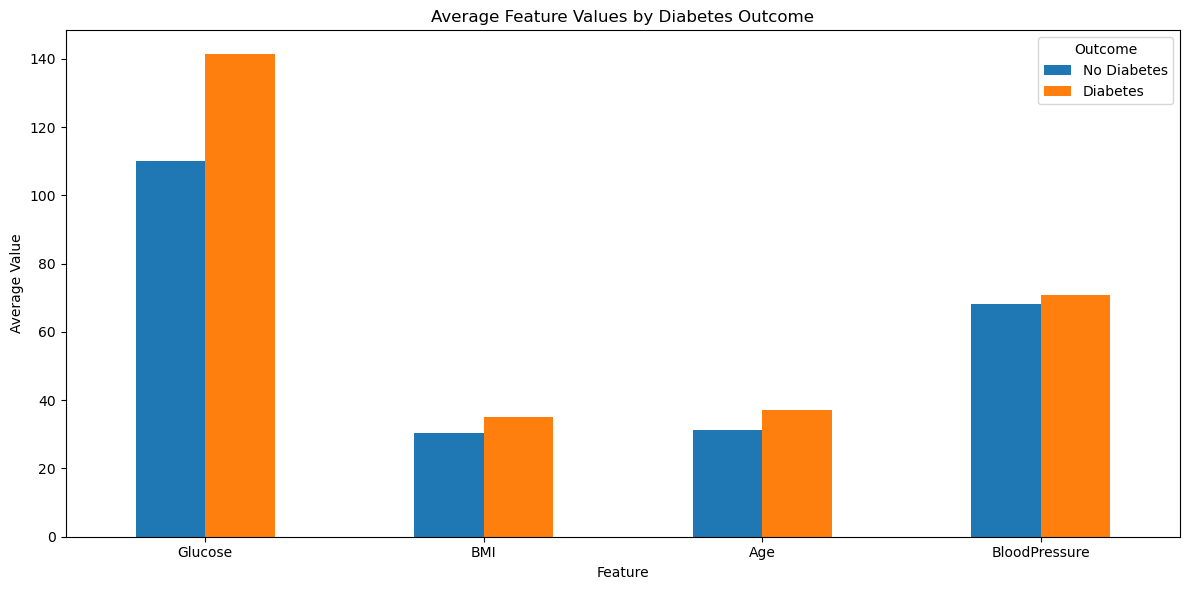

Outcome,0,1
Glucose,109.9800,141.257463
BMI,30.3042,35.142537
Age,31.1900,37.067164
BloodPressure,68.1840,70.824627


In [14]:
# Bar plots showing average feature values by outcome
grouped_means = data.groupby("Outcome")[selected_features].mean().T

grouped_means.plot(kind="bar", figsize=(12, 6))
plt.title("Average Feature Values by Diabetes Outcome")
plt.xlabel("Feature")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Outcome", labels=["No Diabetes", "Diabetes"])
plt.tight_layout()
plt.show()

display(grouped_means)

### EDA Observations
- The dataset contains **768 observations and 9 columns**.
- `Outcome` is the binary target variable.
- Several medical measurements such as Glucose, BloodPressure, SkinThickness, Insulin and BMI contain zero values that can be medically implausible. These are treated as missing values during preprocessing.
- Glucose generally shows a strong relationship with diabetes outcome.
- BMI and Age also provide useful discriminatory information.
- Box plots indicate potential outliers, which tree-based boosting algorithms can generally handle without requiring feature scaling.

## 3. Data Preprocessing

In [15]:
# Replace medically implausible zero values with NaN for selected variables.
# Pregnancies and Outcome are allowed to contain zero naturally.
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

processed = data.copy()
processed[zero_as_missing] = processed[zero_as_missing].replace(0, np.nan)

print("Missing values after treating invalid zeros as missing:")
display(processed.isnull().sum().to_frame("Missing Count"))

Missing values after treating invalid zeros as missing:


,Missing Count
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [16]:
# Separate predictors and target
X = processed.drop(columns="Outcome")
y = processed["Outcome"]

# Numeric imputation using median values
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Remaining missing values after median imputation:", X_imputed.isnull().sum().sum())
display(X_imputed.head())

Remaining missing values after median imputation: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,125.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,125.0,26.6,0.351,31.0
2,8.0,183.0,64.0,29.0,125.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0


### Encoding and Scaling

## 4. Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training set: (614, 8)
Testing set : (154, 8)

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


## 5. Baseline LightGBM and XGBoost Models

In [24]:
# Create baseline models
lgbm_model = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    verbosity=-1
)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    n_jobs=-1
)

# Train models
lgbm_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions
lgbm_pred = lgbm_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("Baseline models trained successfully.")

NameError: name 'LGBMClassifier' is not defined

In [20]:
# Evaluation helper function
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

baseline_results = pd.DataFrame([
    evaluate_model("LightGBM Baseline", y_test, lgbm_pred, lgbm_prob),
    evaluate_model("XGBoost Baseline", y_test, xgb_pred, xgb_prob)
])

display(baseline_results.round(4))

NameError: name 'lgbm_pred' is not defined

In [21]:
# Detailed classification reports
print("LightGBM Classification Report")
print(classification_report(y_test, lgbm_pred, target_names=["No Diabetes", "Diabetes"]))

print("XGBoost Classification Report")
print(classification_report(y_test, xgb_pred, target_names=["No Diabetes", "Diabetes"]))

LightGBM Classification Report


NameError: name 'lgbm_pred' is not defined

## 6. Confusion Matrices

NameError: name 'lgbm_pred' is not defined

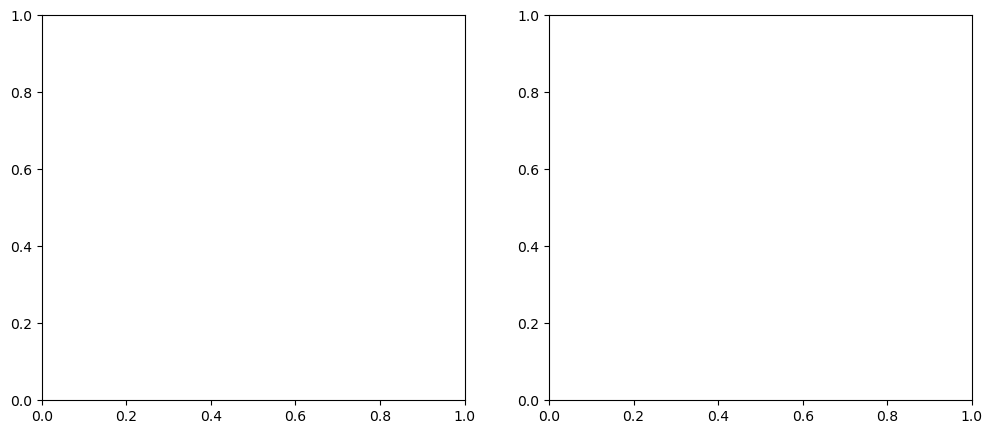

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, lgbm_pred),
    display_labels=["No Diabetes", "Diabetes"]
).plot(ax=axes[0], values_format="d")
axes[0].set_title("LightGBM Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, xgb_pred),
    display_labels=["No Diabetes", "Diabetes"]
).plot(ax=axes[1], values_format="d")
axes[1].set_title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

## 7. Cross-Validation

In [26]:
# Stratified 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_models = {
    "LightGBM": lgbm_model,
    "XGBoost": xgb_model
}

cv_summary = []

for name, model in cv_models.items():
    scores = cross_validate(model, X_imputed, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_summary.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results = pd.DataFrame(cv_summary)
display(cv_results.round(4))

NameError: name 'lgbm_model' is not defined

## 8. Hyperparameter Tuning

In [27]:
# Hyperparameter grids
lgbm_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05],
    "num_leaves": [15, 31],
    "max_depth": [-1, 5],
    "min_child_samples": [10, 20]
}

xgb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Use F1 as the tuning objective because it balances precision and recall.
lgbm_search = GridSearchCV(
    LGBMClassifier(objective="binary", random_state=42, verbosity=-1),
    lgbm_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0
)

xgb_search = GridSearchCV(
    XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=-1),
    xgb_param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0
)

print("Running LightGBM GridSearchCV...")
lgbm_search.fit(X_train, y_train)

print("Running XGBoost GridSearchCV...")
xgb_search.fit(X_train, y_train)

print("\nBest LightGBM parameters:")
print(lgbm_search.best_params_)
print("Best LightGBM CV F1:", round(lgbm_search.best_score_, 4))

print("\nBest XGBoost parameters:")
print(xgb_search.best_params_)
print("Best XGBoost CV F1:", round(xgb_search.best_score_, 4))

NameError: name 'LGBMClassifier' is not defined

In [ ]:
# Evaluate tuned models on the untouched test set
best_lgbm = lgbm_search.best_estimator_
best_xgb = xgb_search.best_estimator_

tuned_lgbm_pred = best_lgbm.predict(X_test)
tuned_xgb_pred = best_xgb.predict(X_test)

tuned_lgbm_prob = best_lgbm.predict_proba(X_test)[:, 1]
tuned_xgb_prob = best_xgb.predict_proba(X_test)[:, 1]

tuned_results = pd.DataFrame([
    evaluate_model("LightGBM Tuned", y_test, tuned_lgbm_pred, tuned_lgbm_prob),
    evaluate_model("XGBoost Tuned", y_test, tuned_xgb_pred, tuned_xgb_prob)
])

display(tuned_results.round(4))

## 9. Final Model Comparison

In [ ]:
# Combine baseline and tuned test-set results
comparison = pd.concat([baseline_results, tuned_results], ignore_index=True)
display(comparison.round(4))

In [28]:
# Visual comparison of test-set metrics
metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

plot_df = comparison.set_index("Model")[metric_cols]
ax = plot_df.plot(kind="bar", figsize=(13, 6))
plt.title("LightGBM vs XGBoost Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

NameError: name 'comparison' is not defined

In [ ]:
# ROC curves for tuned models
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, tuned_lgbm_prob, name="LightGBM Tuned"
)
RocCurveDisplay.from_predictions(
    y_test, tuned_xgb_prob, name="XGBoost Tuned"
)

plt.title("ROC Curve: Tuned LightGBM vs Tuned XGBoost")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.show()

In [ ]:
# Confusion matrices for tuned models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, tuned_lgbm_pred),
    display_labels=["No Diabetes", "Diabetes"]
).plot(ax=axes[0], values_format="d")
axes[0].set_title("Tuned LightGBM")

ConfusionMatrixDisplay(
    confusion_matrix(y_test, tuned_xgb_pred),
    display_labels=["No Diabetes", "Diabetes"]
).plot(ax=axes[1], values_format="d")
axes[1].set_title("Tuned XGBoost")

plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

In [ ]:
# Feature importance from tuned LightGBM
lgbm_importance = pd.Series(
    best_lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=lgbm_importance.values, y=lgbm_importance.index)
plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(lgbm_importance.to_frame("Importance"))

In [ ]:
# Feature importance from tuned XGBoost
xgb_importance = pd.Series(
    best_xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importance.values, y=xgb_importance.index)
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(xgb_importance.to_frame("Importance"))

## 11. Comparative Analysis and Interpretation

### LightGBM
LightGBM is a gradient boosting framework designed for efficient training and strong predictive performance. It uses histogram-based learning and leaf-wise tree growth. It can be especially efficient on large and high-dimensional datasets.

**Strengths:**
- Fast training and prediction.
- Efficient memory usage.
- Strong performance on structured/tabular data.
- Handles nonlinear feature relationships effectively.

**Weaknesses:**
- Leaf-wise growth can overfit smaller datasets if hyperparameters are not controlled.
- Parameter tuning can be sensitive.

### XGBoost
XGBoost is a highly optimized gradient boosting implementation that uses regularization and several techniques to improve predictive accuracy and control overfitting.

**Strengths:**
- Excellent performance on tabular datasets.
- Strong regularization capabilities.
- Robust and widely used for classification and regression.
- Flexible hyperparameter control.

**Weaknesses:**
- Can require more computation than LightGBM.
- Many hyperparameters may make tuning more involved.

### Practical Implications
For diabetes prediction, **recall is particularly important** because a false negative means a patient who may have diabetes is classified as not having diabetes. Precision and F1-score are also useful because they provide additional information about the balance between false positives and false negatives.

The final model should therefore not be selected only by accuracy. The tuned model with the most appropriate balance of **recall, F1-score and ROC-AUC**, while maintaining acceptable precision, is generally preferable for a screening-oriented application.

## 12. Final Conclusion

This assignment compared LightGBM and XGBoost for binary diabetes classification.

The workflow included:
- Loading and understanding the diabetes dataset.
- Checking missing values and duplicates.
- Exploring distributions using histograms and box plots.
- Studying feature relationships with diabetes outcome.
- Treating medically implausible zero measurements as missing and imputing them using the median.
- Splitting the data using a stratified train-test split.
- Training baseline LightGBM and XGBoost classifiers.
- Evaluating accuracy, precision, recall, F1-score and ROC-AUC.
- Performing 5-fold cross-validation.
- Using GridSearchCV for hyperparameter optimization.
- Comparing tuned models using performance charts and ROC curves.
- Examining feature importance.

### Overall Finding
Both algorithms are powerful choices for structured medical classification data. The best model should be selected using the **actual test-set and cross-validation results produced in this notebook**, with special attention to recall and F1-score in a diabetes-screening context.